# Banking Customer Analytics & Churn Risk Insights
### Consulting-Style Data Analysis for Retail Banking



## 1. Business Problem & Objective

In today’s competitive banking environment, customer retention is as important as acquiring new customers. Even a small increase in customer churn can lead to significant revenue loss, especially when high-value customers exit the bank.

The objective of this project is to analyze customer data from a retail bank to understand why customers are leaving (churn) and to identify key demographic and behavioral factors associated with churn. By studying customer characteristics such as age, tenure, account balance, product usage, and activity status, this analysis aims to uncover patterns that can help the bank proactively identify at-risk customers.

The insights derived from this analysis can support:

Early identification of high churn-risk customers

Improved customer engagement and retention strategies

Data-driven decision-making for business and marketing teams

This project is framed as a consulting-style data analytics exercise, similar to how data analysts support banking and financial services clients in real-world business scenarios.

## 2. Dataset Overview

The dataset used in this project is a Banking Customer Churn dataset, which contains customer-level information related to demographics, account details, product usage, and churn status.

Each row in the dataset represents an individual bank customer, and the columns describe various attributes that may influence customer behavior and retention.

Key Features in the Dataset

CustomerId: Unique identifier for each customer

CreditScore: Credit score of the customer, indicating creditworthiness

Geography: Country or region where the customer is located

Gender: Gender of the customer

Age: Age of the customer

Tenure: Number of years the customer has been associated with the bank

Balance: Account balance held by the customer

NumOfProducts: Number of bank products used by the customer

HasCrCard: Whether the customer owns a credit card (1 = Yes, 0 = No)

IsActiveMember: Indicates whether the customer is an active user of bank services

EstimatedSalary: Estimated annual salary of the customer

Exited: Target variable indicating customer churn (1 = Exited, 0 = Retained)

Certain columns such as RowNumber and Surname do not contribute to analytical insights and will be excluded during data preprocessing.

The dataset provides a realistic representation of customer behavior in a retail banking context and is well-suited for performing exploratory data analysis, segmentation, and churn risk assessment.

## 3. Data Cleaning & Preparation


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#display settings
pd.set_option('display.max_columns',None)

#Load dataset
df = pd.read_csv("data/Churn_Modelling.csv")

#dataset preview
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Dataset Shape and Info

In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### Drop Irrelevant columns

In [6]:
df = df.drop(columns=['RowNumber','CustomerId','Surname'])

### Check for Missing/Null values

In [7]:
df.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### “The dataset contains no missing values, allowing direct analysis without imputation.”

### Data type Correction

In [8]:
df['Geography'] = df['Geography'].astype('category')
df['Gender'] = df['Gender'].astype('category')

### Feature Engineering

In [9]:
df['Age_group'] = pd.cut(df['Age'],
                         bins=[18,30,45,60,100],
                         labels=['Young','Mid','Senior','Elder'])

df['Balance_flag'] = df['Balance'].apply(lambda x:"Zero balance" if x == 0 else "Has balance")
df['Engagement_level'] = df['NumOfProducts'].apply(lambda x:"low" if x <= 1 else "High")


### Target Variable Check

In [10]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

## 4. Exploratory Data Analysis (EDA)
The following analysis examines how customer activity status influences churn behavior.


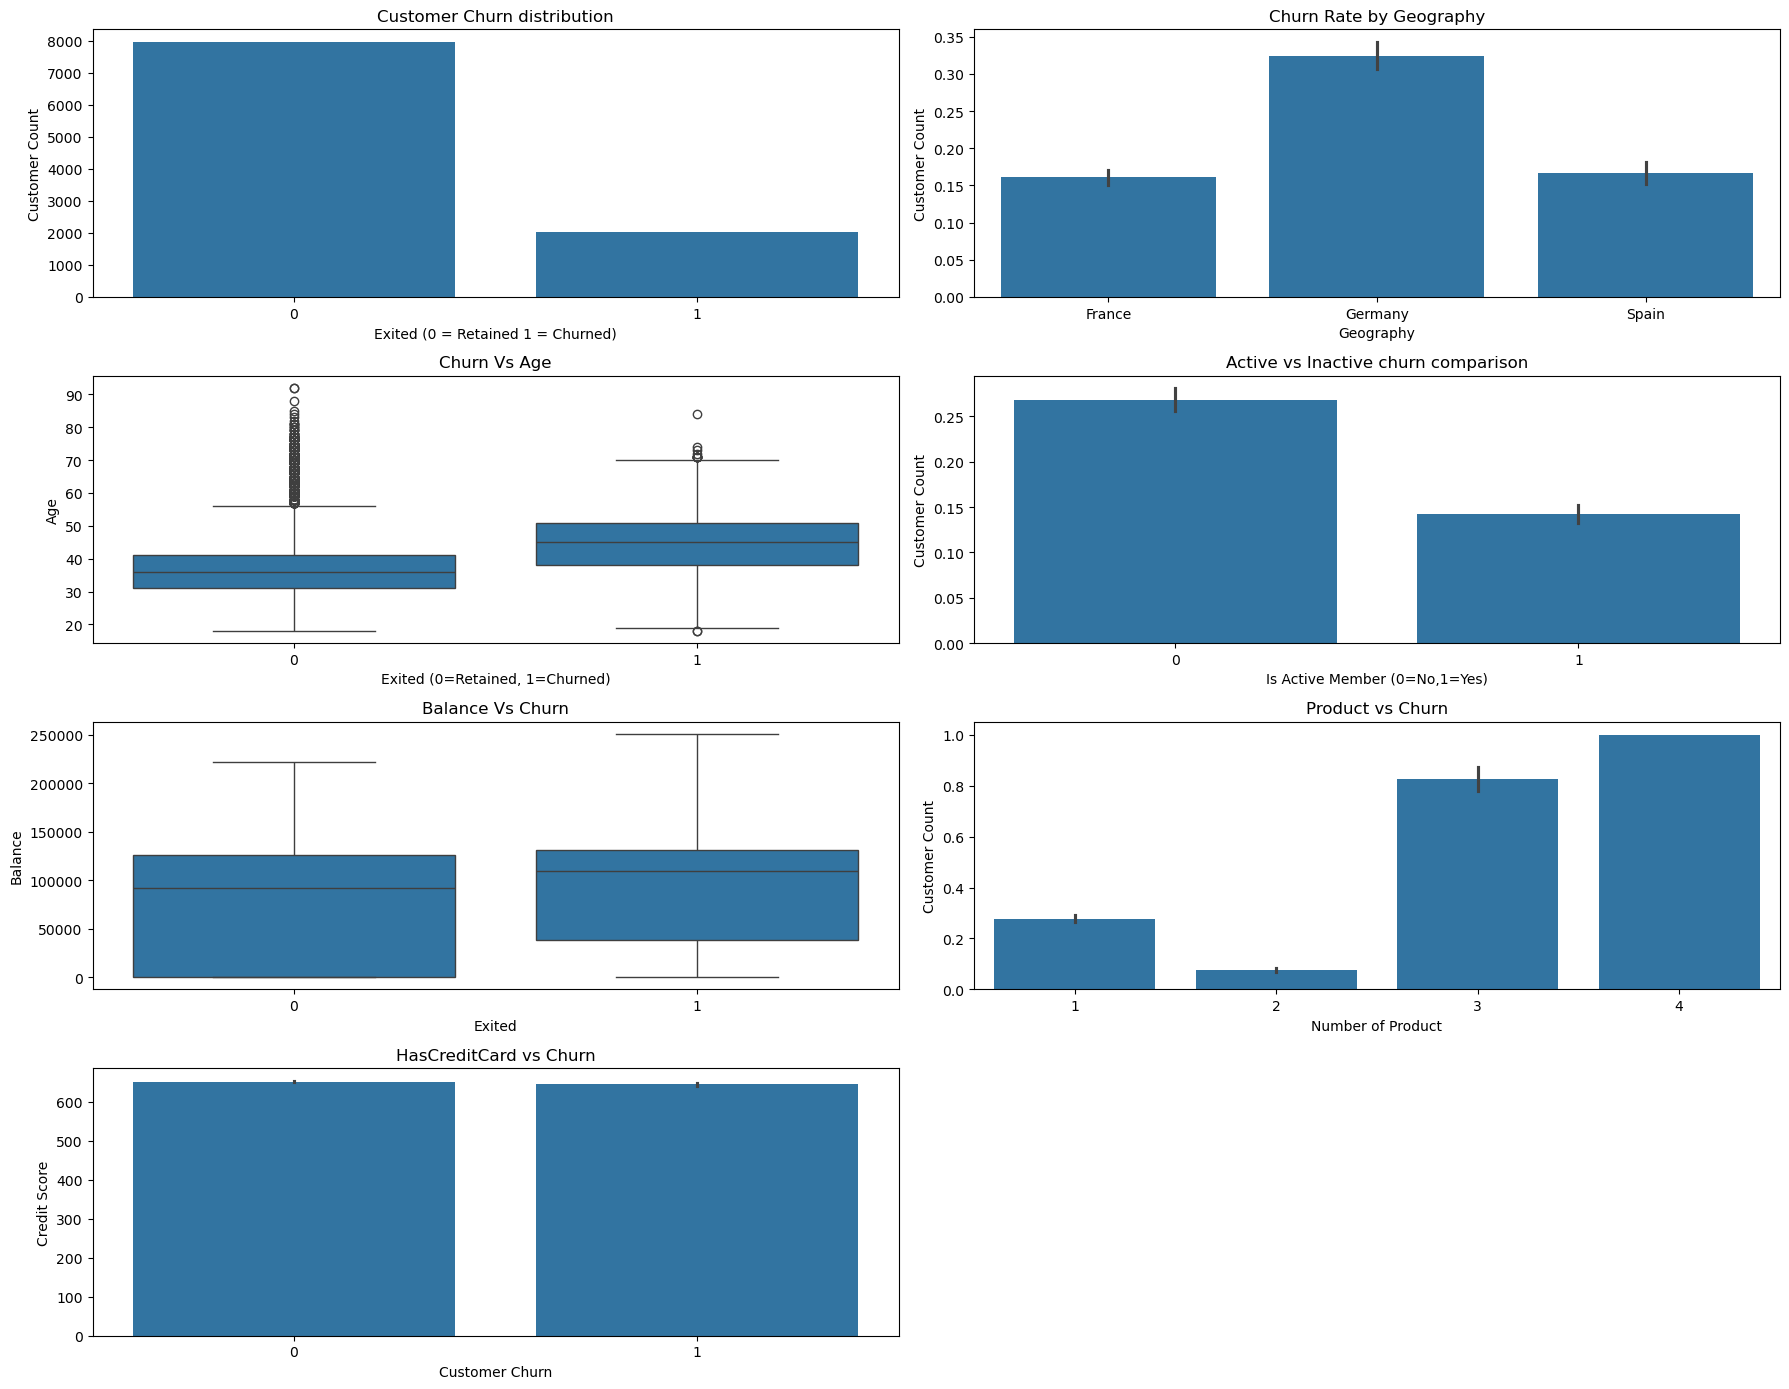

In [37]:
fig,axes = plt.subplots(4,2,figsize=(18,14))
axes = axes.flatten()

# 1.Churn Distribution
sns.countplot(x="Exited",data=df,ax=axes[0])
axes[0].set_title("Customer Churn distribution")
axes[0].set_xlabel("Exited (0 = Retained 1 = Churned)")
axes[0].set_ylabel("Customer Count")

# 2.Churn rate by Geography
sns.barplot(x="Geography",y="Exited",data=df,estimator=np.mean,ax=axes[1])
axes[1].set_title("Churn Rate by Geography")
axes[1].set_xlabel("Geography")
axes[1].set_ylabel("Customer Count")

# 3.Age Vs Churn
sns.boxplot(x='Exited',y='Age',data=df,ax=axes[2])
axes[2].set_title("Churn Vs Age")
axes[2].set_xlabel("Exited (0=Retained, 1=Churned)")
axes[2].set_ylabel("Age")

# 4.Active vs Inactive churn comparison
sns.barplot(x="IsActiveMember",y='Exited',data=df,estimator=np.mean,ax=axes[3])
axes[3].set_title("Active vs Inactive churn comparison")
axes[3].set_xlabel("Is Active Member (0=No,1=Yes)")
axes[3].set_ylabel("Customer Count")


# 5.Balance vs Churn
sns.boxplot(x='Exited',y='Balance',data=df,ax=axes[4])
axes[4].set_title("Balance Vs Churn")
axes[4].set_xlabel("Exited")
axes[4].set_ylabel("Balance")


# 6.Products vs Churn
sns.barplot(x="NumOfProducts",y='Exited',data=df,ax=axes[5])
axes[5].set_title("Product vs Churn")
axes[5].set_xlabel("Number of Product")
axes[5].set_ylabel("Customer Count")

# 7.CreditScore Vs Churn
sns.barplot(x="Exited",y="CreditScore",data=df,ax=axes[6])
axes[6].set_title("HasCreditCard vs Churn")
axes[6].set_xlabel("Customer Churn")
axes[6].set_ylabel("Credit Score")

fig.delaxes(axes[7])
plt.tight_layout()


In [24]:
#Age analysis is performed using capped age values to minimize the impact of extreme outliers.
df['Age_capped'] = df['Age'].clip(lower=18, upper=80)

### **EDA Summary:**

The dataset shows an imbalance between retained and churned customers, which is typical in real-world banking scenarios. 
This highlights the importance of identifying early churn risk indicators rather than reacting after customers exit.

Churn rates vary significantly across regions, suggesting that geographic or regional factors may influence customer retention. 
This indicates a need for region-specific retention strategies.

The age variable contained a small number of extreme values that could disproportionately influence analysis results. 
To maintain data integrity while reducing the impact of outliers, age values were capped within a realistic range 
based on typical retail banking demographics. This approach preserves customer records while ensuring robust analysis.

Customers who churn tend to be older on average compared to retained customers, suggesting higher churn risk among 
mid-to-senior age groups.

Inactive customers exhibit significantly higher churn rates, indicating customer engagement as a critical driver 
of retention.

A notable portion of customers with higher account balances have exited the bank, highlighting potential revenue risk 
if high-value customers are not adequately engaged.

Customers using fewer products show higher churn rates, suggesting opportunities for cross-selling and product bundling 
to improve retention.

Churned customers tend to have slightly lower credit scores, indicating a potential relationship between credit profile 
and customer retention.


## 5. Churn Risk Indicators & Customer Segmentation

**🔹5.1 Identifying Key Churn Risk Indicators**

Based on EDA, the following factors show strong association with churn:
1. Inactive membership
2. Higher age groups
3. Low number of products
4. Certain geographic regions
5. High balance but low engagement

We now translate these observations into risk indicators.

**🔹 5.2 Creating a Simple Churn Risk Flag (Business Logic)**

Instead of jumping into complex ML, we define rule-based risk conditions, similar to how early warning systems work in banks.
**Risk Logic (explainable & realistic)**

A customer is considered High Risk if:
1. Inactive member
2. AND age above 40
3. AND number of products ≤ 1

In [25]:
df['ChurnRiskFlag'] = np.where(
    (df['IsActiveMember'] == 0) &
    (df['Age_capped'] > 40) &
    (df['NumOfProducts'] <= 1),
    "High Risk",
    "Low Risk"
)

**🔹 5.3 Churn Rate by Risk Segment**

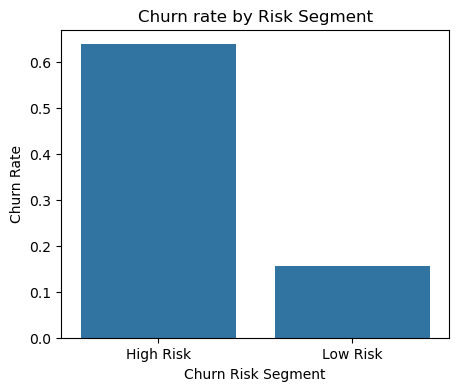

In [28]:
risk_churn = df.groupby('ChurnRiskFlag')['Exited'].mean().reset_index()

plt.figure(figsize=(5,4))
sns.barplot(x="ChurnRiskFlag",y="Exited",data=risk_churn)
plt.title("Churn rate by Risk Segment")
plt.xlabel("Churn Risk Segment")
plt.ylabel("Churn Rate")
plt.show()

Customers classified as High Risk exhibit significantly higher churn rates compared to Low Risk customers. 
This validates the effectiveness of simple, behavior-driven risk indicators in identifying churn-prone segments.


**🔹 5.4 Value-Based Segmentation**

Define customer value using balance & salary

In [29]:
df['CustomerValue'] = np.where(
    (df['Balance'] > df['Balance'].median()) &
    (df['EstimatedSalary'] > df['EstimatedSalary'].median()),
    "High Risk",
    "Low Risk"
)

**🔹 5.5 Risk vs Value Matrix**

In [31]:
pivot_table = pd.crosstab(
    df['CustomerValue'],
    df['ChurnRiskFlag'],
    normalize='index'
)

pivot_table

ChurnRiskFlag,High Risk,Low Risk
CustomerValue,,
High Risk,0.124404,0.875596
Low Risk,0.090326,0.909674


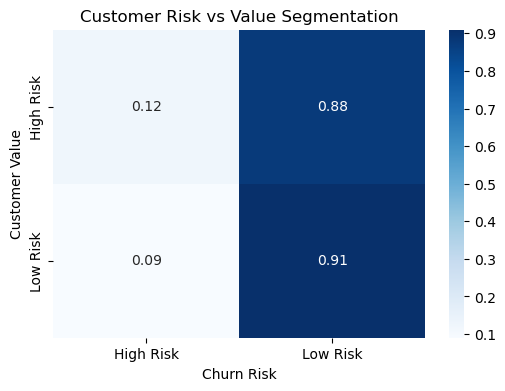

In [33]:
plt.figure(figsize=(6,4))
sns.heatmap(pivot_table,fmt='.2f',annot=True,cmap='Blues')
plt.title("Customer Risk vs Value Segmentation")
plt.ylabel("Customer Value")
plt.xlabel("Churn Risk")
plt.show()

The segmentation reveals a critical group of High Value – High Risk customers. 
These customers represent a significant revenue risk if not proactively retained.

Conversely, Low Value – High Risk customers may require cost-effective retention strategies, 
while High Value – Low Risk customers should be nurtured to maintain long-term loyalty.


## 6. Key Insights

1. **Customer inactivity is the strongest indicator of churn**  
   Inactive customers show significantly higher churn rates compared to active customers, highlighting engagement as a critical driver of retention.

2. **Older customers exhibit higher churn risk**  
   Customers in mid-to-senior age groups are more likely to exit, suggesting the need for tailored engagement strategies for this demographic.

3. **Customers using fewer products are more likely to churn**  
   Single-product customers demonstrate higher churn rates, indicating opportunities for cross-selling and deeper product adoption to improve retention.

4. **Geographic differences play a role in customer churn**  
   Certain regions experience consistently higher churn rates, suggesting that regional factors or localized service issues may impact customer satisfaction.

5. **High-value customers are not immune to churn**  
   A notable portion of customers with higher account balances and salaries have exited the bank, representing potential revenue loss if not proactively managed.

6. **Simple rule-based risk indicators effectively identify churn-prone segments**  
   Customers classified as High Risk based on inactivity, age, and low product usage exhibit substantially higher churn, validating the effectiveness of behavior-driven risk segmentation.


## 7. Business Recommendations

Based on the insights derived from the analysis, the following data-driven recommendations are proposed to help the bank reduce customer churn and improve retention:

1. **Implement early-warning systems for inactive customers**  
   Customer inactivity emerged as the strongest churn indicator. The bank should proactively monitor inactivity patterns and trigger early engagement initiatives such as personalized reminders, targeted offers, or relationship manager outreach.

2. **Prioritize retention of high-value, high-risk customers**  
   High-value customers exhibiting churn risk represent significant potential revenue loss. These customers should be prioritized through tailored retention strategies, including exclusive benefits, customized financial products, or proactive service interventions.

3. **Enhance product adoption through cross-selling strategies**  
   Customers using fewer banking products demonstrate higher churn rates. Encouraging multi-product usage through bundled offerings or personalized recommendations can strengthen customer relationships and reduce churn likelihood.

4. **Adopt age-segmented engagement strategies**  
   Older customer segments show higher churn risk, indicating the need for age-specific engagement approaches such as simplified digital experiences, advisory services, or targeted communication channels.

5. **Develop region-specific retention initiatives**  
   Geographic variations in churn suggest that localized factors may influence customer behavior. Conducting region-level diagnostics and implementing customized regional strategies can improve overall retention performance.

6. **Leverage explainable, rule-based risk segmentation**  
   Simple, transparent risk indicators based on customer behavior can be effectively used alongside advanced analytics to support decision-making, enabling business teams to act quickly and confidently.


## 8. Conclusion

This project analyzed retail banking customer data to understand the key drivers of customer churn and identify at-risk segments using exploratory and diagnostic analytics.

Through comprehensive data cleaning, exploratory analysis, and rule-based risk segmentation, the study highlighted customer inactivity, low product engagement, age-related patterns, and geographic differences as the primary factors influencing churn. Importantly, the analysis revealed that even high-value customers are susceptible to churn when engagement levels decline.

The insights and recommendations presented in this project demonstrate how explainable, data-driven analysis can support proactive customer retention strategies in banking environments. Such an approach enables business teams to make informed decisions, prioritize high-risk segments, and improve long-term customer relationships without relying solely on complex predictive models.
